<a href="https://colab.research.google.com/github/nishanthreddy16/Customer-Personality-Sales-Prediction-System-ML/blob/main/Ml_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [183]:
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

# **View Dataset**

In [184]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# **Check Shape**

In [185]:
df.shape

(2240, 29)

# **Check Columns**

In [186]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

# **Check Missing Values**

In [187]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# **Data Cleaning**

In [188]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

# **Create Total Sales Column**

In [189]:
df['Total_Sales'] = (
      df['MntWines'] +
      df['MntFruits'] +
      df['MntMeatProducts'] +
      df['MntFishProducts'] +
      df['MntSweetProducts'] +
      df['MntGoldProds']

)

# **Select Simple Linear Regression Variables**

In [190]:
X = df[['Income']]
y = df['Total_Sales']

# **Train Test Split**

In [191]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

# **Build Linear Regression Model**

In [192]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

# **Predictions**

In [193]:
y_pred = lr.predict(X_test)

# **Best Fit Line**

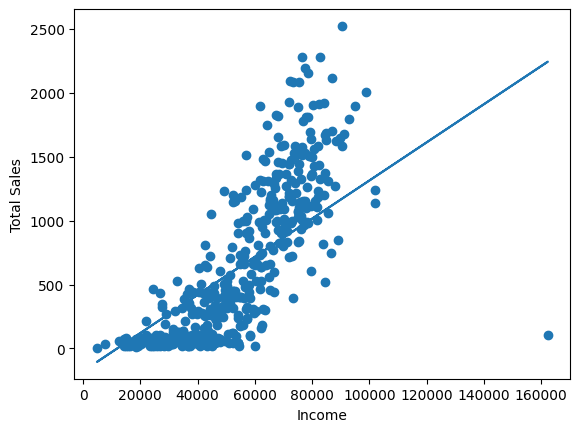

In [194]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Income")
plt.ylabel("Total Sales")
plt.show()

# **Check Accuracy**

In [195]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.5429222836269859

# **Residual Analysis**

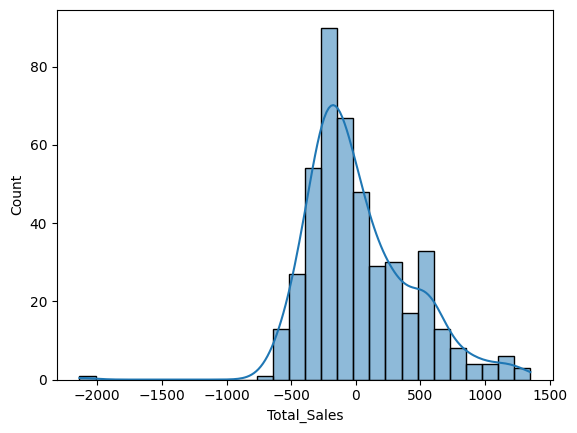

In [196]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.show()

# **Select Multiple Features**

In [197]:
X = df[['Income',
        'NumWebPurchases',
        'NumStorePurchases',
        'NumWebVisitsMonth']]

y = df['Total_Sales']

# **Train Test Split**

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

# **Train MLR Model**

In [199]:
mlr = LinearRegression()

mlr.fit(X_train, y_train)

LinearRegression()

# **Predictions**

In [200]:
y_pred = mlr.predict(X_test)

# **Model Accuracy**

In [201]:
r2_score(y_test, y_pred)

0.6650961269672404

# **Correlation Matrix**

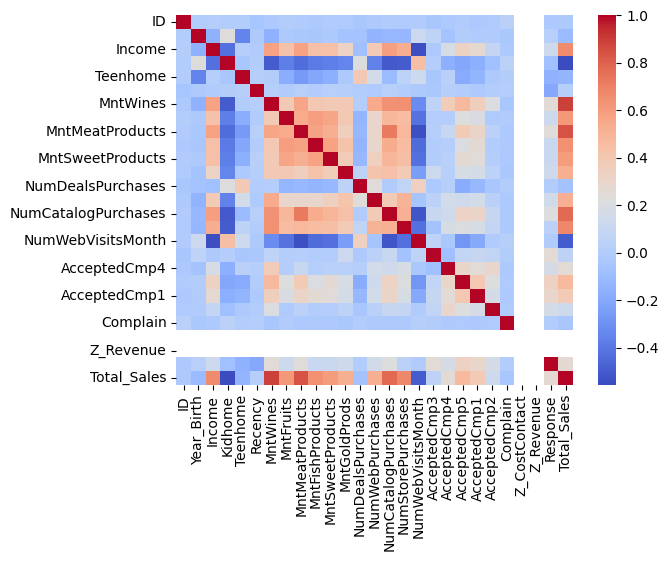

In [202]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

# **Feature Selection using RFE**

In [203]:
from sklearn.feature_selection import RFE

model = LinearRegression()

rfe = RFE(model, n_features_to_select=3)

rfe.fit(X, y)

RFE(estimator=LinearRegression(), n_features_to_select=3)

# **Selected Features**

In [204]:
rfe.support_

array([False,  True,  True,  True])

# **Create Binary Target**

In [205]:
df['High_Sales'] = np.where(df['Total_Sales'] > 2000, 1, 0)

# **Select Features**

In [206]:
X = df[['Income',
        'NumWebPurchases',
        'NumStorePurchases']]

y = df['High_Sales']

# **Train Test Split**

In [207]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

# **Train Logistic Regression**

In [208]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

# **Predictions**

In [209]:
y_pred = log_model.predict(X_test)

# **Confusion Matrix**

In [210]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[438,   0],
       [ 10,   0]])

# **Accuracy Score**

In [211]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9776785714285714

# **Classification Report**

In [212]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       438
           1       0.00      0.00      0.00        10

    accuracy                           0.98       448
   macro avg       0.49      0.50      0.49       448
weighted avg       0.96      0.98      0.97       448



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **ROC Curve**

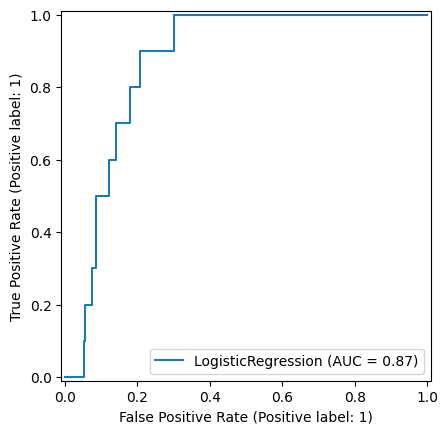

In [213]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.show()

# **Train Naive Bayes Model**

In [214]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

# **Predictions**

In [215]:
nb_pred = nb.predict(X_test)

# **Accuracy**

In [216]:
accuracy_score(y_test, nb_pred)

0.9754464285714286

# **Select Clustering Features**

In [217]:
cluster_data = df[['Income', 'Total_Sales']]

# **Scale Data**

In [218]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

## **Elbow Method**

In [219]:
from sklearn.cluster import KMeans

sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

# **Plot Elbow Graph**

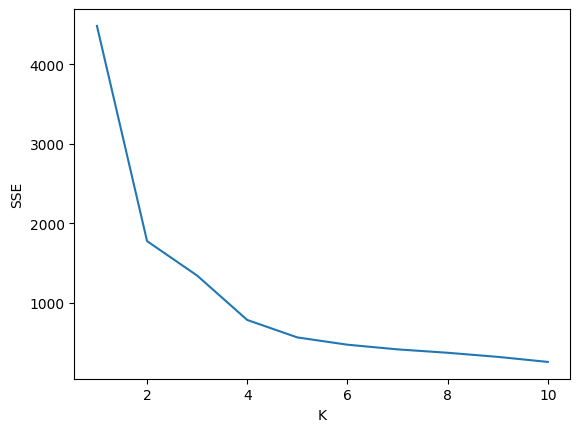

In [220]:
plt.plot(range(1,11), sse)
plt.xlabel("K")
plt.ylabel("SSE")
plt.show()

# **Apply K-Means**

In [221]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

# **Visualize Clusters**

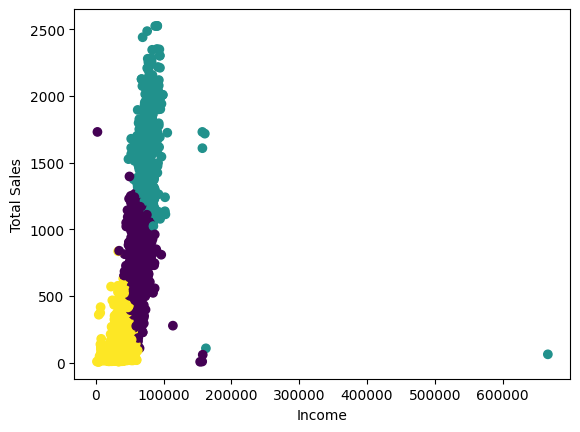

In [222]:
plt.scatter(df['Income'], df['Total_Sales'],
            c=df['Cluster'])

plt.xlabel("Income")
plt.ylabel("Total Sales")
plt.show()

# **Hierarchical Clustering**

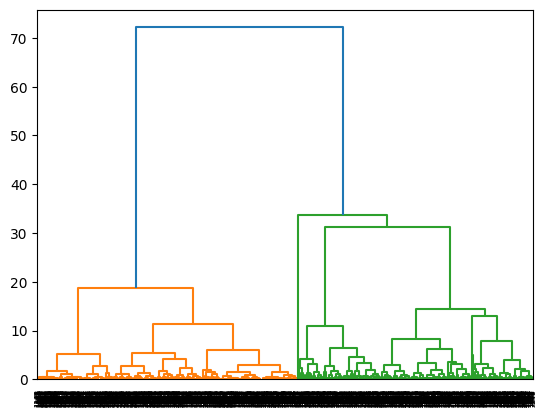

In [223]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

dendrogram(linked)
plt.show()

# **DBSCAN**

In [224]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

df['DBSCAN_Cluster'] = db.fit_predict(scaled_data)

# **PCA**

In [225]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

# **PCA Visualization**

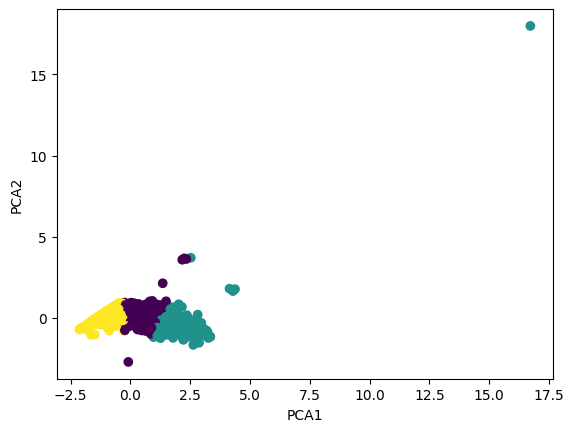

In [226]:
plt.scatter(pca_data[:,0], pca_data[:,1],
            c=df['Cluster'])

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

# **Silhouette Score**

In [227]:
from sklearn.metrics import silhouette_score

silhouette_score(scaled_data, df['Cluster'])

np.float64(0.5021957011385674)